  0%|          | 0/1.0 [00:00<?, ?it/s]              

FieldCollection(ScalarField(...), ScalarField(...))
v grad at y direciton is [[ 0.02231205  0.15631101 -0.07967961 ...  0.27196294 -0.30934178
  -0.27816825]
 [-0.16583005 -0.29593077  0.10946631 ...  0.01919067  0.00394923
  -0.08167882]
 [ 0.36626924  0.26711518  0.06365986 ...  0.22156392  0.32192681
  -0.10625095]
 ...
 [-0.07301778  0.07795006  0.04771712 ... -0.22565484  0.17018395
   0.26704198]
 [-0.01528556  0.09266971  0.14385941 ...  0.23883981  0.01834029
   0.07466224]
 [-0.06143968  0.25258194  0.35455402 ...  0.10526171  0.3694862
  -0.00555415]]
grid is [[ 0.5  1.5  2.5 ... 29.5 30.5 31.5]
 [ 0.5  1.5  2.5 ... 29.5 30.5 31.5]
 [ 0.5  1.5  2.5 ... 29.5 30.5 31.5]
 ...
 [ 0.5  1.5  2.5 ... 29.5 30.5 31.5]
 [ 0.5  1.5  2.5 ... 29.5 30.5 31.5]
 [ 0.5  1.5  2.5 ... 29.5 30.5 31.5]]


100%|██████████| 1.0/1.0 [00:00<00:00,  3.61it/s]

state_data has shape: (2, 32, 32)


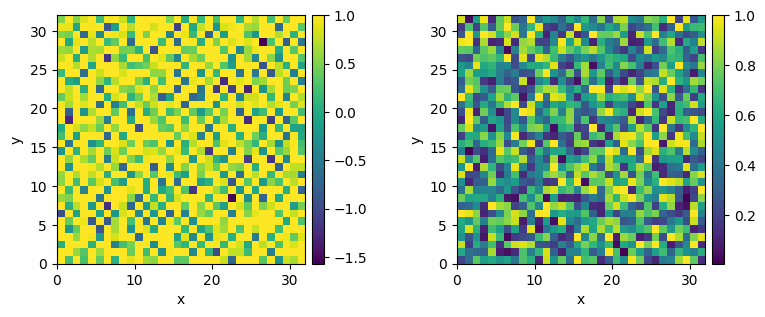

In [ ]:
from pde import FieldCollection, PDEBase, UnitGrid


class FitzhughNagumoPDE(PDEBase):
    """FitzHugh–Nagumo model with diffusive coupling"""

    def __init__(self, stimulus=0.5, τ=10, a=0, b=0, bc="auto_periodic_neumann"):
        super().__init__()
        self.bc = bc
        self.stimulus = stimulus
        self.τ = τ
        self.a = a
        self.b = b

    def evolution_rate(self, state, t=0):
        print(state)
        v, w = state  # membrane potential and recovery variable
        
        print(f"v grad at y direciton is {v.gradient(bc=self.bc).data[1]}")
        print(f"grid is {state.grid.cell_coords[:, :, 1]}")
        v_t = v.laplace(bc=self.bc) + v - v**3 / 3 - w + self.stimulus
        w_t = (v + self.a - self.b * w) / self.τ

        return FieldCollection([v_t, w_t])
    
    def make_post_step_hook(self, state, backend):
        """Create a hook function that is called after every time step."""

        def post_step_hook(state_data, t, post_step_data):
            """Limit state 1 and abort when standard deviation exceeds 1."""
            print(f"state_data has shape: {state_data.shape}")
            i = state_data > 1  # get violating entries
            overshoot = (state_data[i] - 1).sum()  # get total correction
            state_data[i] = 1  # limit data entries
            post_step_data += overshoot  # accumulate total correction
            if post_step_data > 400:
                # Abort simulation when correction exceeds 400
                # Note that the `post_step_data` of the previous step will be returned.
                raise StopIteration
            return state_data, post_step_data

        return post_step_hook, 0.0  # hook function and initial value for data


grid = UnitGrid([32, 32])
state = FieldCollection.scalar_random_uniform(2, grid)

eq = FitzhughNagumoPDE()
result = eq.solve(state, t_range=1, dt=1)
result.plot()


100%|██████████| 0.1/0.1 [00:00<00:00, 20.86it/s]    

(64, 64)


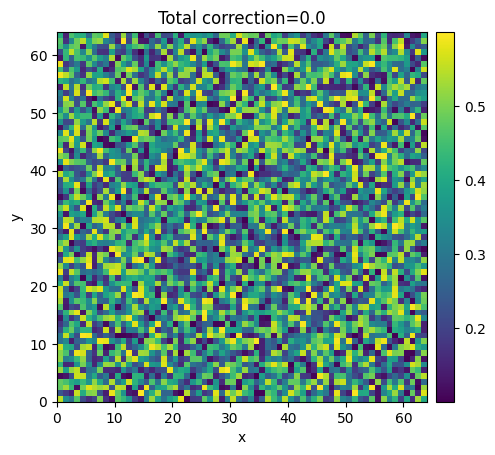

In [5]:
from pde import PDEBase, ScalarField, UnitGrid


class CustomPDE(PDEBase):
    def make_post_step_hook(self, state, backend):
        """Create a hook function that is called after every time step."""

        def post_step_hook(state_data, t, post_step_data):
            """Limit state 1 and abort when standard deviation exceeds 1."""
            print(state_data.shape)
            i = state_data > 1  # get violating entries
            overshoot = (state_data[i] - 1).sum()  # get total correction
            state_data[i] = 1  # limit data entries
            post_step_data += overshoot  # accumulate total correction
            if post_step_data > 400:
                # Abort simulation when correction exceeds 400
                # Note that the `post_step_data` of the previous step will be returned.
                raise StopIteration
            return state_data, post_step_data

        return post_step_hook, 0.0  # hook function and initial value for data

    def evolution_rate(self, state, t=0):
        """Evaluate the right hand side of the evolution equation."""
        return state.__class__(state.grid, data=1)  # constant growth


grid = UnitGrid([64, 64])  # generate grid
state = ScalarField.random_uniform(grid, 0.0, 0.5)  # generate initial condition

eq = CustomPDE()
result = eq.solve(state, dt=0.1, t_range=0.1)
result.plot(title=f"Total correction={eq.diagnostics['solver']['post_step_data']}")

In [8]:
from pde import CartesianGrid
import numpy as np
grid= CartesianGrid([(-100/2,  100/2), (-30/2,  30/2)], [50,15])
print(np.zeros(grid.shape))

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [12]:
from pde import ScalarField
c1 = 10
print(ScalarField.from_expression(grid=grid,expression=f"exp(-({c1} * x**2 + y**2))").data)

[[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [0.

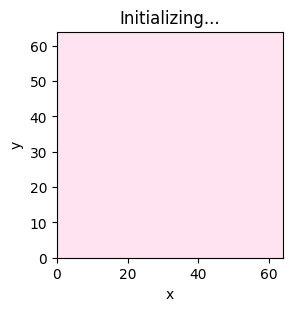

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

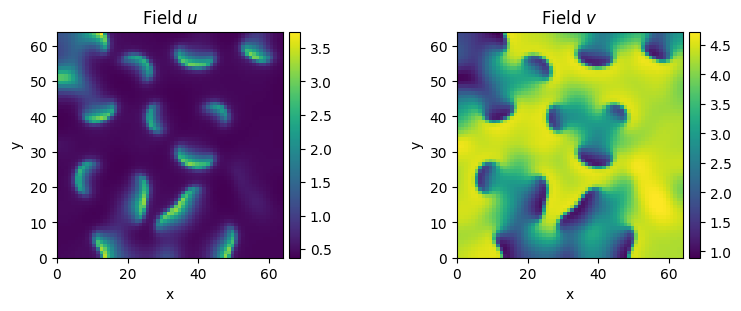

In [2]:
import numpy as np

from pde import FieldCollection, PDEBase, PlotTracker, ScalarField, UnitGrid


class BrusselatorPDE(PDEBase):
    """Brusselator with diffusive mobility."""

    def __init__(self, a=1, b=3, diffusivity=None, bc="auto_periodic_neumann"):
        super().__init__()
        self.a = a
        self.b = b
        self.diffusivity = [1, 0.1] if diffusivity is None else diffusivity
        self.bc = bc  # boundary condition

    def get_initial_state(self, grid):
        """Prepare a useful initial state."""
        u = ScalarField(grid, self.a, label="Field $u$")
        v = self.b / self.a + 0.1 * ScalarField.random_normal(grid, label="Field $v$")
        return FieldCollection([u, v])

    def evolution_rate(self, state, t=0):
        """Pure python implementation of the PDE."""
        u, v = state
        rhs = state.copy()
        d0, d1 = self.diffusivity
        rhs[0] = d0 * u.laplace(self.bc) + self.a - (self.b + 1) * u + u**2 * v
        rhs[1] = d1 * v.laplace(self.bc) + self.b * u - u**2 * v
        return rhs

    def make_evolution_rate(self, state, backend):
        """Compilable implementation of the PDE."""
        d0, d1 = self.diffusivity
        a, b = self.a, self.b
        laplace = state.grid.make_operator(
            "laplace", bc=self.bc, backend=backend, dtype=state.dtype
        )

        def pde_rhs(state_data, t):
            u = state_data[0]
            v = state_data[1]

            rate_u = d0 * laplace(u) + a - (1 + b) * u + v * u**2
            rate_v = d1 * laplace(v) + b * u - v * u**2
            return np.stack((rate_u, rate_v))

        return pde_rhs


# initialize state
grid = UnitGrid([64, 64])
eq = BrusselatorPDE(diffusivity=[1, 0.1])
state = eq.get_initial_state(grid)

# simulate the pde
tracker = PlotTracker(interrupts=1, plot_args={"kind": "merged", "vmin": 0, "vmax": 5})
sol = eq.solve(state, t_range=20, dt=1e-3, tracker=tracker)
sol.plot()